In [1]:
import os, json, glob, pickle, random
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import timm

from skimage import measure

# Device сонголт: CUDA (NVIDIA) → MPS (Apple Silicon) → CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
elif device.type == 'mps':
    print('Apple Silicon GPU (MPS) ашиглаж байна')
else:
    print('CPU ашиглаж байна — inference удаан байж болзошгүй')

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps
Apple Silicon GPU (MPS) ашиглаж байна


## 1. Тохиргоо — замууд + hyperparameter

In [2]:
# === Local project root ===
# Энэ notebook нь LAST/Turshilt_3/ дотор тул project root нь нэг шат дээш.
PROJECT_ROOT = str(Path.cwd().parent if Path.cwd().name == 'Turshilt_3' else Path.cwd())
# Шаардлагатай бол гараар тааруулна:
# PROJECT_ROOT = '/Users/ariuntungalag/Desktop/LAST'
print('PROJECT_ROOT =', PROJECT_ROOT)

# ============================================================
# ХУРД: FAST_MODE = True  → 1 fold, TTA OFF — ~10-18x хурдан, ачаалал бага
#       FAST_MODE = False → 3 fold ensemble + бүрэн TTA — хамгийн нарийвчлалтай (удаан)
# ============================================================
FAST_MODE = True

# Classification (T3_classification)
CLS_CKPT_DIR    = f'{PROJECT_ROOT}/T3_classification/checkpoints'
CLS_FOLDS       = [f'{CLS_CKPT_DIR}/fold{i}.pth' for i in range(3)]
CLS_SUMMARY     = f'{CLS_CKPT_DIR}/cv_summary.json'
CLS_MODEL_NAME  = 'convnext_base.fb_in22k_ft_in1k_384'
CLS_IMG_SIZE    = 384
CLS_TTA_SCALES  = (320, 384, 448)
CLS_TTA_HFLIP   = True

# Segmentation (Hybrid ResNet U-Net)
SEG_CKPT        = f'{PROJECT_ROOT}/Turshilt_3/hybrid_unet_final.pth'
SEG_ENCODER     = 'resnet50'
SEG_IMG_SIZE    = 384
SEG_THRESHOLD   = 0.5
SEG_USE_TTA     = True

# Severity (RandomForest)
SEV_CKPT        = f'{PROJECT_ROOT}/severity_classifier.pkl'

# Demo-д ашиглах жишээ зургийн folder (заавал биш)
FA_TEST_DIR     = f'{PROJECT_ROOT}/fracatlas-DatasetNinja/test'

# Common
IMAGENET_MEAN   = np.array([0.485, 0.456, 0.406])
IMAGENET_STD    = np.array([0.229, 0.224, 0.225])
WL_P_LOW        = 1.0   # 16-bit window/level
WL_P_HIGH       = 99.0

# --- Зам бүр байгаа эсэхийг шалгая (бүх 3 fold) ---
_checks = [(f'fold{i}', fp) for i, fp in enumerate(CLS_FOLDS)]
_checks += [('seg ckpt', SEG_CKPT), ('severity pkl', SEV_CKPT)]
for label, p in _checks:
    print(('  ✓' if os.path.exists(p) else '  ✗ ОЛДСОНГҮЙ:'), f'{label} → {p}')

# --- FAST_MODE-г хэрэгжүүлнэ ---
if FAST_MODE:
    CLS_FOLDS      = CLS_FOLDS[:1]      # зөвхөн 1 fold ачаална (3x бага унших)
    CLS_TTA_SCALES = (384,)             # 1 scale
    CLS_TTA_HFLIP  = False              # hflip-гүй → нийт 1 view
    SEG_USE_TTA    = False              # segmentation TTA-гүй (4 view → 1)
    print('⚡ FAST_MODE ON — 1 fold, TTA off (хурдан). Бүрэн нарийвчлалд FAST_MODE=False болго.')
else:
    SEG_USE_TTA    = True
    print('🐢 FAST_MODE OFF — 3 fold ensemble + бүрэн TTA (удаан, хамгийн нарийвчлалтай).')

# CV summary-аас calibrated threshold ачаалъя
try:
    with open(CLS_SUMMARY, 'r') as f:
        _summary = json.load(f)
    CLS_THRESHOLD = float(_summary['threshold'])
    print(f'Loaded calibrated CLS threshold = {CLS_THRESHOLD:.4f} (CV AUC = {_summary["cv_auc"]:.4f})')
except FileNotFoundError:
    CLS_THRESHOLD = 0.5
    print('cv_summary.json олдсонгүй — default threshold 0.5 ашиглана')

PROJECT_ROOT = /Users/ariuntungalag/Desktop/LAST
  ✓ fold0 → /Users/ariuntungalag/Desktop/LAST/T3_classification/checkpoints/fold0.pth
  ✓ fold1 → /Users/ariuntungalag/Desktop/LAST/T3_classification/checkpoints/fold1.pth
  ✓ fold2 → /Users/ariuntungalag/Desktop/LAST/T3_classification/checkpoints/fold2.pth
  ✓ seg ckpt → /Users/ariuntungalag/Desktop/LAST/Turshilt_3/hybrid_unet_final.pth
  ✓ severity pkl → /Users/ariuntungalag/Desktop/LAST/severity_classifier.pkl
⚡ FAST_MODE ON — 1 fold, TTA off (хурдан). Бүрэн нарийвчлалд FAST_MODE=False болго.
Loaded calibrated CLS threshold = 0.2476 (CV AUC = 0.9887)


## 2. Зураг унших туслахууд (16-bit window/level → 8-bit RGB)

GRAZPEDWRI dataset 16-bit PNG, бусад нь 8-bit. Бүгдийг нэг функцээр зохицуулна.

In [4]:
def read_image(path):
    """16-bit / 8-bit / grayscale / RGB бүх төрлийг 8-bit RGB numpy буцаана."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(path)

    if img.dtype == np.uint16:
        nonzero = img[img > 0]
        if len(nonzero) > 100:
            p_low, p_high = np.percentile(nonzero, [WL_P_LOW, WL_P_HIGH])
        else:
            p_low, p_high = img.min(), img.max()
        if p_high <= p_low:
            p_high = p_low + 1
        img = np.clip(img, p_low, p_high)
        img = ((img - p_low) / (p_high - p_low) * 255).astype(np.uint8)

    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.ndim == 3:
        if img.shape[2] == 4:
            img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)
        elif img.shape[2] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        elif img.shape[2] == 1:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return img


def imagenet_normalize(img):
    """img: HWC float [0,1] - HWC float ImageNet-normalized."""
    return ((img - IMAGENET_MEAN) / IMAGENET_STD).astype(np.float32)

## 3. CLASSIFICATION — ConvNeXt-Base × 3-fold ensemble + TTA

Архитектур: timm `convnext_base.fb_in22k_ft_in1k_384` + LayerNorm + Linear(1).

TTA: scales=(320, 384, 448) × hflip=(False, True) = **6 view averaging**.
Ensemble: 3 fold-ийн дундаж probability.

In [5]:
class FractureModel(nn.Module):
    def __init__(self, model_name=CLS_MODEL_NAME, dropout=0.2):
        super().__init__()
        self.backbone = timm.create_model(
            model_name, pretrained=False, num_classes=0, global_pool='avg'
        )
        feat_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 1),
        )

    def forward(self, x):
        f = self.backbone(x)
        return self.head(f).squeeze(-1)


def load_cls_ensemble():
    models = []
    for fp in CLS_FOLDS:
        m = FractureModel().to(device).eval()
        sd = torch.load(fp, map_location=device, weights_only=False)
        # EMA weights хадгалагдсан байж болно
        if isinstance(sd, dict):
            if 'ema_state_dict' in sd:
                state = sd['ema_state_dict']
            elif 'model_state_dict' in sd:
                state = sd['model_state_dict']
            elif 'state_dict' in sd:
                state = sd['state_dict']
            else:
                state = sd
        else:
            state = sd
        # Module wrap-ийг хасах
        state = {k.replace('module.', '').replace('_orig_mod.', ''): v for k, v in state.items()}
        m.load_state_dict(state, strict=False)
        models.append(m)
        print(f'  ✓ Loaded {os.path.basename(fp)}')
    return models

print('Classification ensemble ачааллаж байна...')
cls_models = load_cls_ensemble()
print(f'Total folds: {len(cls_models)}')

Classification ensemble ачааллаж байна...
  ✓ Loaded fold0.pth
Total folds: 1


In [6]:
def build_cls_tta_transform(size, hflip=False):
    tfs = [
        A.LongestMaxSize(max_size=size),
        A.PadIfNeeded(min_height=size, min_width=size,
                      border_mode=cv2.BORDER_CONSTANT, fill=0),
    ]
    if hflip:
        tfs.append(A.HorizontalFlip(p=1.0))
    tfs.extend([
        A.Normalize(mean=IMAGENET_MEAN.tolist(), std=IMAGENET_STD.tolist()),
        ToTensorV2(),
    ])
    return A.Compose(tfs)


@torch.no_grad()
def classify_image(image_or_path, models=None):
    """Нэг зураг → fracture probability (ensemble + TTA дундаж)."""
    if models is None:
        models = cls_models
    if isinstance(image_or_path, str):
        img = read_image(image_or_path)
    else:
        img = image_or_path

    views = []
    for s in CLS_TTA_SCALES:
        views.append((s, False))
        if CLS_TTA_HFLIP:
            views.append((s, True))

    all_probs = []
    for scale, flip in views:
        tf = build_cls_tta_transform(scale, hflip=flip)
        x = tf(image=img)['image'].unsqueeze(0).to(device)
        for m in models:
            with autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logit = m(x)
            all_probs.append(torch.sigmoid(logit.float()).cpu().item())

    return float(np.mean(all_probs))

## 4. SEGMENTATION — Hybrid ResNet50 U-Net + 4-view TTA

Phase A: SAM pretrain (3K зураг) → Phase B: FracAtlas refine (574 зураг).
Inference: 4-view TTA (original, hflip, +5°, -5°).

In [7]:
def build_seg_model():
    return smp.Unet(
        encoder_name=SEG_ENCODER,
        encoder_weights=None,  # checkpoint-аас бүх weight орно
        in_channels=3,
        classes=1,
    )


def load_seg_model():
    m = build_seg_model().to(device).eval()
    sd = torch.load(SEG_CKPT, map_location=device, weights_only=False)
    if isinstance(sd, dict) and 'model_state_dict' in sd:
        state = sd['model_state_dict']
    elif isinstance(sd, dict) and 'state_dict' in sd:
        state = sd['state_dict']
    else:
        state = sd
    state = {k.replace('module.', ''): v for k, v in state.items()}
    m.load_state_dict(state, strict=False)
    return m

print('Segmentation model ачааллаж байна...')
seg_model = load_seg_model()
print('   Hybrid U-Net loaded')

Segmentation model ачааллаж байна...
   Hybrid U-Net loaded


In [8]:
def seg_preprocess(img_rgb_uint8, size=SEG_IMG_SIZE):
    """uint8 RGB  ImageNet-normalized tensor (1,3,H,W)."""
    pil = Image.fromarray(img_rgb_uint8).resize((size, size), Image.BILINEAR)
    arr = np.array(pil, dtype=np.float32) / 255.0
    arr = imagenet_normalize(arr)
    arr = np.transpose(arr, (2, 0, 1))[None]
    return torch.from_numpy(arr).to(device)


@torch.no_grad()
def predict_mask_tta(image_or_path, threshold=SEG_THRESHOLD, return_prob=False):
    """Segmentation. SEG_USE_TTA=True үед 4-view TTA (original, hflip, ±5°),
    эс бөгөөс зөвхөн 1 view (хурдан)."""
    if isinstance(image_or_path, str):
        img = read_image(image_or_path)
    else:
        img = image_or_path
    orig_h, orig_w = img.shape[:2]

    x = seg_preprocess(img)
    probs = []

    # 1. Original (үргэлж)
    probs.append(torch.sigmoid(seg_model(x)))

    # 2-4. TTA (зөвхөн SEG_USE_TTA=True үед)
    if globals().get('SEG_USE_TTA', True):
        # Horizontal flip
        xh = torch.flip(x, dims=[-1])
        ph = torch.sigmoid(seg_model(xh))
        probs.append(torch.flip(ph, dims=[-1]))

        # ±5° rotation
        for angle in (5, -5):
            theta = np.deg2rad(angle)
            cos, sin = np.cos(theta), np.sin(theta)
            rot = torch.tensor([[cos, -sin, 0], [sin, cos, 0]],
                               dtype=torch.float32, device=device).unsqueeze(0)
            grid = F.affine_grid(rot, x.shape, align_corners=False)
            xr = F.grid_sample(x, grid, align_corners=False)
            pr = torch.sigmoid(seg_model(xr))
            # inverse rotate
            rot_inv = torch.tensor([[cos, sin, 0], [-sin, cos, 0]],
                                   dtype=torch.float32, device=device).unsqueeze(0)
            grid_inv = F.affine_grid(rot_inv, pr.shape, align_corners=False)
            pr = F.grid_sample(pr, grid_inv, align_corners=False)
            probs.append(pr)

    prob_avg = torch.stack(probs).mean(0)[0, 0].cpu().numpy()  # (H, W)
    # Анхны зураг руу resize
    prob_full = cv2.resize(prob_avg, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
    mask = (prob_full > threshold).astype(np.uint8)
    if return_prob:
        return mask, prob_full
    return mask

## 5. SEVERITY + HEALING — морфологийн feature + RandomForest classifier

**10 morphological feature:** area_px, area_pct, n_components, largest_comp_pct,
major_axis, minor_axis, aspect_ratio, eccentricity, solidity, bone_region.

**4 severity class** + recovery weeks lookup-аар final report үүсгэнэ.

In [9]:
def extract_features(mask):
    """Binary mask → 10 морфологийн feature dict."""
    h, w = mask.shape
    image_area = h * w
    feats = {
        'area_px': 0.0, 'area_pct': 0.0, 'n_components': 0,
        'largest_comp_pct': 0.0, 'major_axis': 0.0, 'minor_axis': 0.0,
        'aspect_ratio': 0.0, 'eccentricity': 0.0, 'solidity': 0.0,
        'bone_region': 0.0,
    }
    if mask.sum() == 0:
        return feats

    feats['area_px']  = float(mask.sum())
    feats['area_pct'] = float(mask.sum() / image_area * 100)

    labels = measure.label(mask)
    props = measure.regionprops(labels)
    feats['n_components'] = len(props)

    if props:
        largest = max(props, key=lambda p: p.area)
        feats['largest_comp_pct'] = float(largest.area / mask.sum() * 100)
        feats['major_axis']       = float(largest.axis_major_length)
        feats['minor_axis']       = float(largest.axis_minor_length)
        feats['aspect_ratio']     = float(largest.axis_major_length /
                                          max(largest.axis_minor_length, 1e-6))
        feats['eccentricity']     = float(largest.eccentricity)
        feats['solidity']         = float(largest.solidity)
        # Bone region — масс байгаа дунд цэгийн босоо хувь
        cy = largest.centroid[0]
        feats['bone_region']      = float(cy / h)

    return feats


# Recovery weeks lookup (severity - (lo_weeks, hi_weeks, desc))
RECOVERY_WEEKS = {
    0: (0,  0,  'Хугарал байхгүй — эмчилгээ шаардлагагүй'),
    1: (2,  4,  'Бага зэргийн хугарал — 4-6 долоо хоног'),
    2: (6,  8,  'Дунд зэргийн хугарал — 7-10 долоо хоног'),
    3: (10, 16, 'Хүнд хугарал — 12-18 долоо хоног (мэс засал хэрэгтэй магадгүй)'),
}


def recovery_weeks(severity):
    return RECOVERY_WEEKS.get(int(severity), (None, None, 'Тодорхойгүй'))

In [10]:
print('Severity classifier ачааллаж байна...')
with open(SEV_CKPT, 'rb') as f:
    sev_bundle = pickle.load(f)
sev_clf      = sev_bundle['classifier']
FEATURE_COLS = sev_bundle['feature_cols']
print(f'  ✓ {type(sev_clf).__name__} | features: {len(FEATURE_COLS)}')
print(f'  ✓ CV accuracy (saved): {sev_bundle.get("cv_accuracy", "N/A")}')


def predict_severity(mask):
    """Mask → (severity_class, feature_dict)."""
    feats = extract_features(mask)
    if feats['area_px'] < 30:
        return 0, feats
    x = np.array([[feats[c] for c in FEATURE_COLS]])
    sev = int(sev_clf.predict(x)[0])
    return sev, feats

Severity classifier ачааллаж байна...
  ✓ RandomForestClassifier | features: 6
  ✓ CV accuracy (saved): 0.9460259344012204


/opt/miniconda3/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 6. End-to-end Pipeline — нэг зураг → бүх үе шат

In [11]:
def predict_full(image_path, verbose=True):
    """X-ray зургийг бүх 3 шатаар явуулаад нэгдсэн dict буцаана."""
    img = read_image(image_path)

    # 1. Classification
    p_fracture = classify_image(img)
    has_fracture = p_fracture >= CLS_THRESHOLD

    result = {
        'image_path': image_path,
        'fracture_prob': p_fracture,
        'fracture_threshold': CLS_THRESHOLD,
        'has_fracture': bool(has_fracture),
    }

    # 2-3. Хэрэв fracture байвал segmentation + severity
    if has_fracture:
        mask, prob_map = predict_mask_tta(img, return_prob=True)
        severity, feats = predict_severity(mask)
        lo, hi, desc = recovery_weeks(severity)
        result.update({
            'mask': mask,
            'mask_prob': prob_map,
            'features': feats,
            'severity_class': severity,
            'recovery_weeks_lo': lo,
            'recovery_weeks_hi': hi,
            'recovery_desc': desc,
        })
    else:
        result.update({
            'mask': None, 'mask_prob': None, 'features': None,
            'severity_class': 0,
            'recovery_weeks_lo': 0, 'recovery_weeks_hi': 0,
            'recovery_desc': 'Хагарал илрээгүй',
        })

    if verbose:
        print(f'File          : {os.path.basename(image_path)}')
        print(f'Fracture prob : {result["fracture_prob"]:.4f}  '
              f'(threshold {CLS_THRESHOLD:.4f})')
        print(f'Has fracture  : {result["has_fracture"]}')
        if has_fracture:
            print(f'Severity      : Class {result["severity_class"]}')
            print(f'Recovery      : {result["recovery_desc"]}')
            print(f'Mask area %   : {result["features"]["area_pct"]:.2f}')
    return result

In [12]:
# 7. Visualization — predict_full үр дүнг 6-panel dashboard болгож харуулах

SEV_NAMES = {0: 'Normal', 1: 'Mild', 2: 'Moderate', 3: 'Severe'}


def _severity_probs(result):
    """4 grade (0..3)-ийн магадлалын вектор буцаана."""
    probs = np.zeros(4, dtype=float)
    feats = result.get('features')
    if (not result['has_fracture']) or feats is None or feats.get('area_px', 0) < 30:
        probs[int(result['severity_class'])] = 1.0
        return probs
    try:
        x = np.array([[feats[c] for c in FEATURE_COLS]])
        p = sev_clf.predict_proba(x)[0]
        for cls, pv in zip(sev_clf.classes_, p):
            if 0 <= int(cls) <= 3:
                probs[int(cls)] = pv
    except Exception:
        probs[int(result['severity_class'])] = 1.0
    if probs.sum() == 0:
        probs[int(result['severity_class'])] = 1.0
    return probs


def visualize_prediction(result, age=None, sex=None, figsize=(18, 9)):
    """6-panel dashboard: classification, segmentation, probability heatmap,
    severity, healing prediction (Gaussian), prediction summary."""
    img = read_image(result['image_path'])
    p = float(result['fracture_prob'])
    has = bool(result['has_fracture'])
    sev = int(result['severity_class'])

    fig, axes = plt.subplots(2, 3, figsize=figsize)

    # --- 1. Classification ---
    ax = axes[0, 0]
    ax.imshow(img)
    color = 'red' if has else 'green'
    conf = (p if has else 1 - p) * 100
    ax.set_title(f"Classification\n{'Fracture' if has else 'Normal'} "
                 f"(confidence: {conf:.1f}%)", color=color, fontweight='bold')
    ax.axis('off')

    # --- 2. Segmentation overlay ---
    ax = axes[0, 1]
    ax.imshow(img)
    area_pct = 0.0
    if has and result.get('mask') is not None:
        ax.imshow(result['mask'], cmap='Reds', alpha=0.45)
        area_pct = float(result['features']['area_pct'])
    ax.set_title(f"Segmentation\nFracture area: {area_pct:.2f}%", fontweight='bold')
    ax.axis('off')

    # --- 3. Fracture probability heatmap ---
    ax = axes[0, 2]
    heat = result.get('mask_prob')
    if heat is None:
        heat = np.zeros(img.shape[:2], dtype=float)
    im = ax.imshow(heat, cmap='hot', vmin=0.0, vmax=1.0)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title("Fracture Probability Heatmap", fontweight='bold')
    ax.axis('off')

    # --- 4. Severity bar chart ---
    ax = axes[1, 0]
    sp = _severity_probs(result)
    bar_colors = ['#bdbdbd' if g != sev else 'gold' for g in range(4)]
    bar_edges  = ['#bdbdbd' if g != sev else 'navy' for g in range(4)]
    ax.bar([f'Grade {g}' for g in range(4)], sp,
           color=bar_colors, edgecolor=bar_edges, linewidth=2)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Probability')
    ax.set_title(f"Severity\nPredicted: Grade {sev} ({SEV_NAMES[sev]})", fontweight='bold')

    # --- 5. Healing prediction (Gaussian) ---
    ax = axes[1, 1]
    lo, hi, desc = recovery_weeks(sev)
    mean = std = ci_lo = ci_hi = 0.0
    if hi and hi > 0:
        mean = (lo + hi) / 2.0
        std = max((hi - lo) / 4.0, 0.5)
        # Нас өгөгдсөн бол эдгэрэлтийн хугацааг бага зэрэг тохируулна (эвристик)
        if age is not None:
            mean *= 1.0 + max(0, age - 30) * 0.01   # 30-аас дээш нас тутамд +1%
        xs = np.linspace(max(0, mean - 4 * std), mean + 4 * std, 300)
        ys = np.exp(-0.5 * ((xs - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))
        ax.fill_between(xs, ys, alpha=0.4, color='steelblue')
        ax.plot(xs, ys, color='steelblue')
        ax.axvline(mean, color='red', linestyle='--', label=f'Predicted: {mean:.1f} weeks')
        ci_lo, ci_hi = max(0.0, mean - 1.96 * std), mean + 1.96 * std
        ax.axvline(ci_lo, color='gray', linestyle=':')
        ax.axvline(ci_hi, color='gray', linestyle=':')
        ax.legend(loc='upper right', fontsize=9)
        ax.set_xlabel('Healing time (weeks)')
        ax.set_ylabel('Probability density')
        pinfo = ''
        if age is not None or sex is not None:
            pinfo = f"\n(Age: {age if age is not None else '?'}, Sex: {sex if sex is not None else '?'})"
        ax.set_title(f"Healing Prediction\n{mean:.1f} ± {std:.1f} weeks{pinfo}",
                     fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Эдгэрэлт шаардлагагүй\n(хугарал илрээгүй)',
                ha='center', va='center', fontsize=13, color='green',
                transform=ax.transAxes)
        ax.set_title("Healing Prediction", fontweight='bold')
        ax.axis('off')

    # --- 6. Prediction summary ---
    ax = axes[1, 2]
    ax.axis('off')
    lines = [
        'PREDICTION SUMMARY', '',
        f"Classification: {'Fracture' if has else 'Normal'}",
        f"  Confidence: {conf:.1f}%",
        f"  P(Normal)   = {1 - p:.3f}",
        f"  P(Fracture) = {p:.3f}", '',
        'Segmentation:',
        f"  Fracture area ratio: {area_pct:.2f}%", '',
        f"Severity: Grade {sev} ({SEV_NAMES[sev]})",
        f"  Grade: {sev} / 3", '',
    ]
    if has and hi and hi > 0:
        lines += [
            f"Healing time: {mean:.1f} weeks",
            f"  Uncertainty: ± {std:.1f}",
            f"  95% CI: [{ci_lo:.1f}, {ci_hi:.1f}]", '',
        ]
    else:
        lines += ['Healing time: 0 weeks', '']
    if age is not None or sex is not None:
        lines += ['Patient info:',
                  f"  Age: {age if age is not None else 'N/A'}",
                  f"  Sex: {sex if sex is not None else 'N/A'}"]
    ax.text(0.02, 0.98, '\n'.join(lines), ha='left', va='top', fontsize=10,
            family='monospace', transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='#ffffe0', edgecolor='#cccc88'))

    plt.tight_layout()
    plt.show()

## 8. PREDICTION DEMO — нэг зургийг бүх pipeline-аар явуулж visualize хийх

FracAtlas test-ээс 10 зураг сонгов (нийт 62 зургаас).

 [1/10] IMG0003564.jpg
File          : IMG0003564.jpg
Fracture prob : 0.4197  (threshold 0.2476)
Has fracture  : True
Severity      : Class 1
Recovery      : Бага зэргийн хугарал — 4-6 долоо хоног
Mask area %   : 0.20


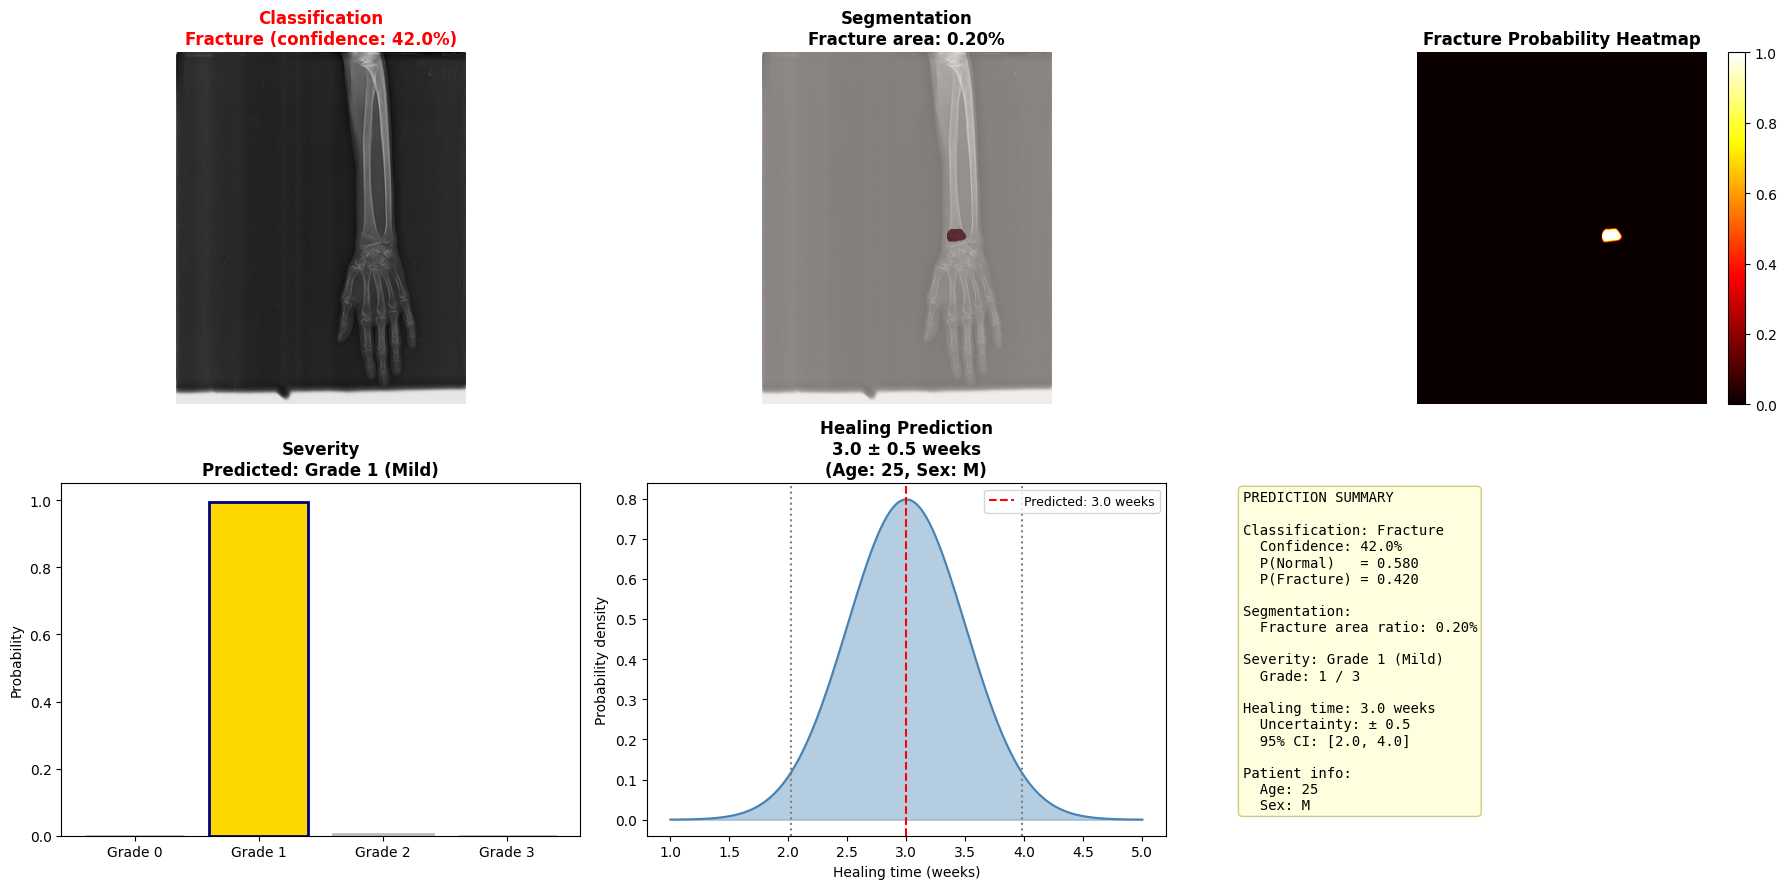


 [2/10] IMG0003312.jpg
File          : IMG0003312.jpg
Fracture prob : 0.8056  (threshold 0.2476)
Has fracture  : True
Severity      : Class 0
Recovery      : Хугарал байхгүй — эмчилгээ шаардлагагүй
Mask area %   : 0.00


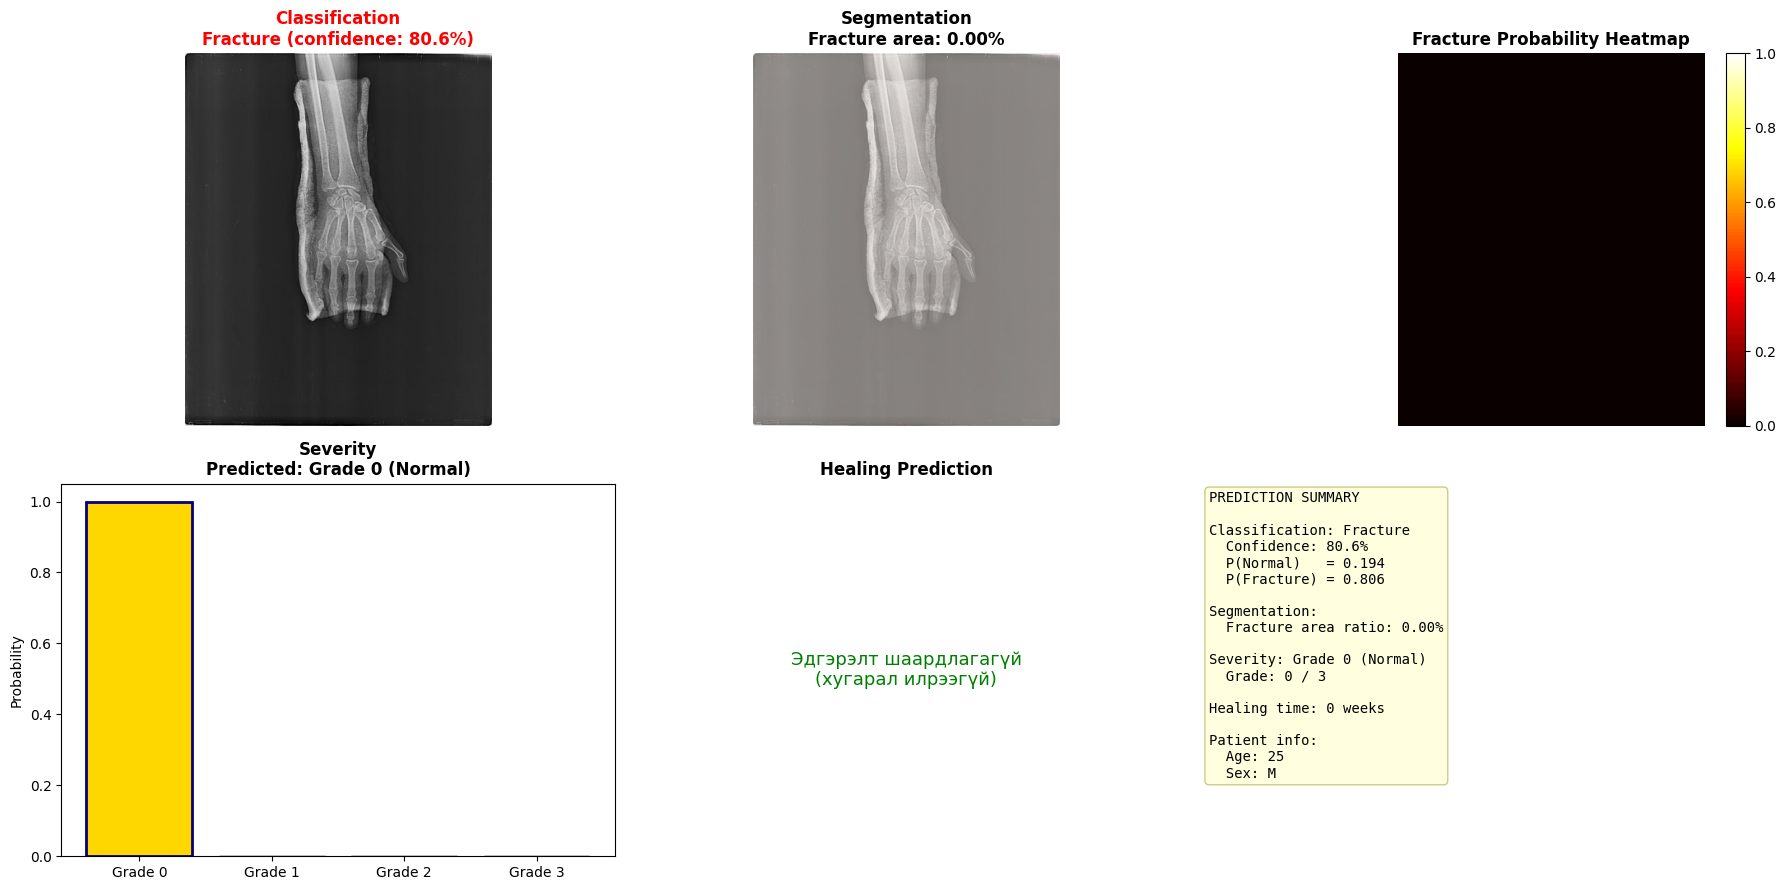


 [3/10] IMG0003298.jpg
File          : IMG0003298.jpg
Fracture prob : 0.0722  (threshold 0.2476)
Has fracture  : False


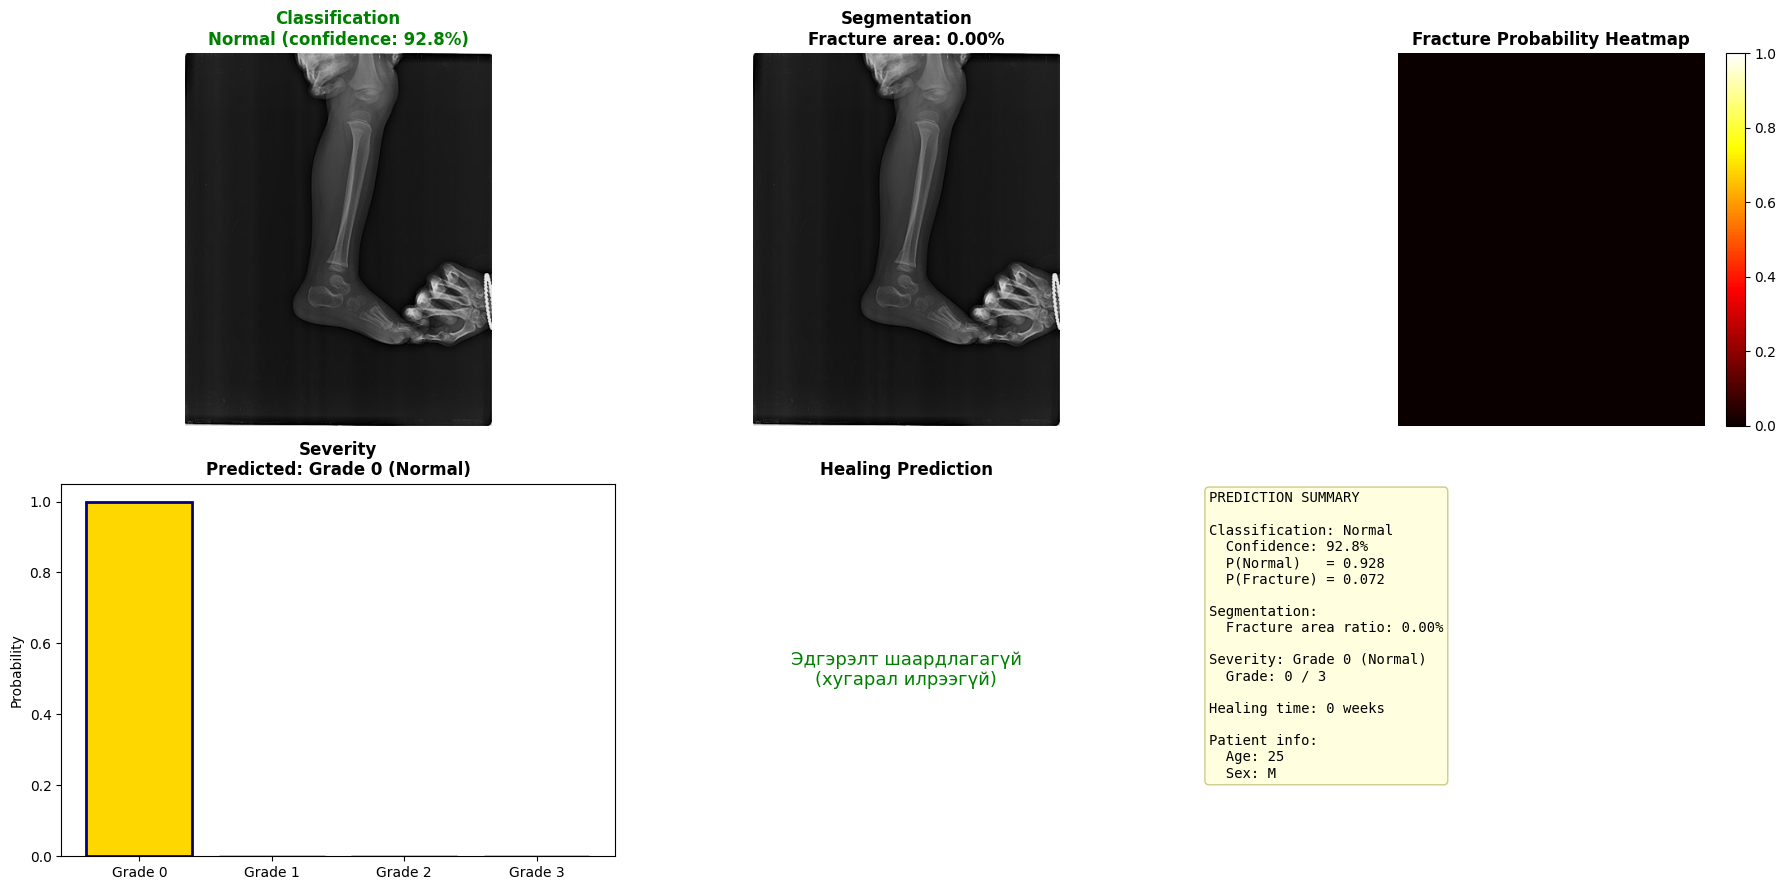


 [4/10] IMG0003619.jpg
File          : IMG0003619.jpg
Fracture prob : 0.2217  (threshold 0.2476)
Has fracture  : False


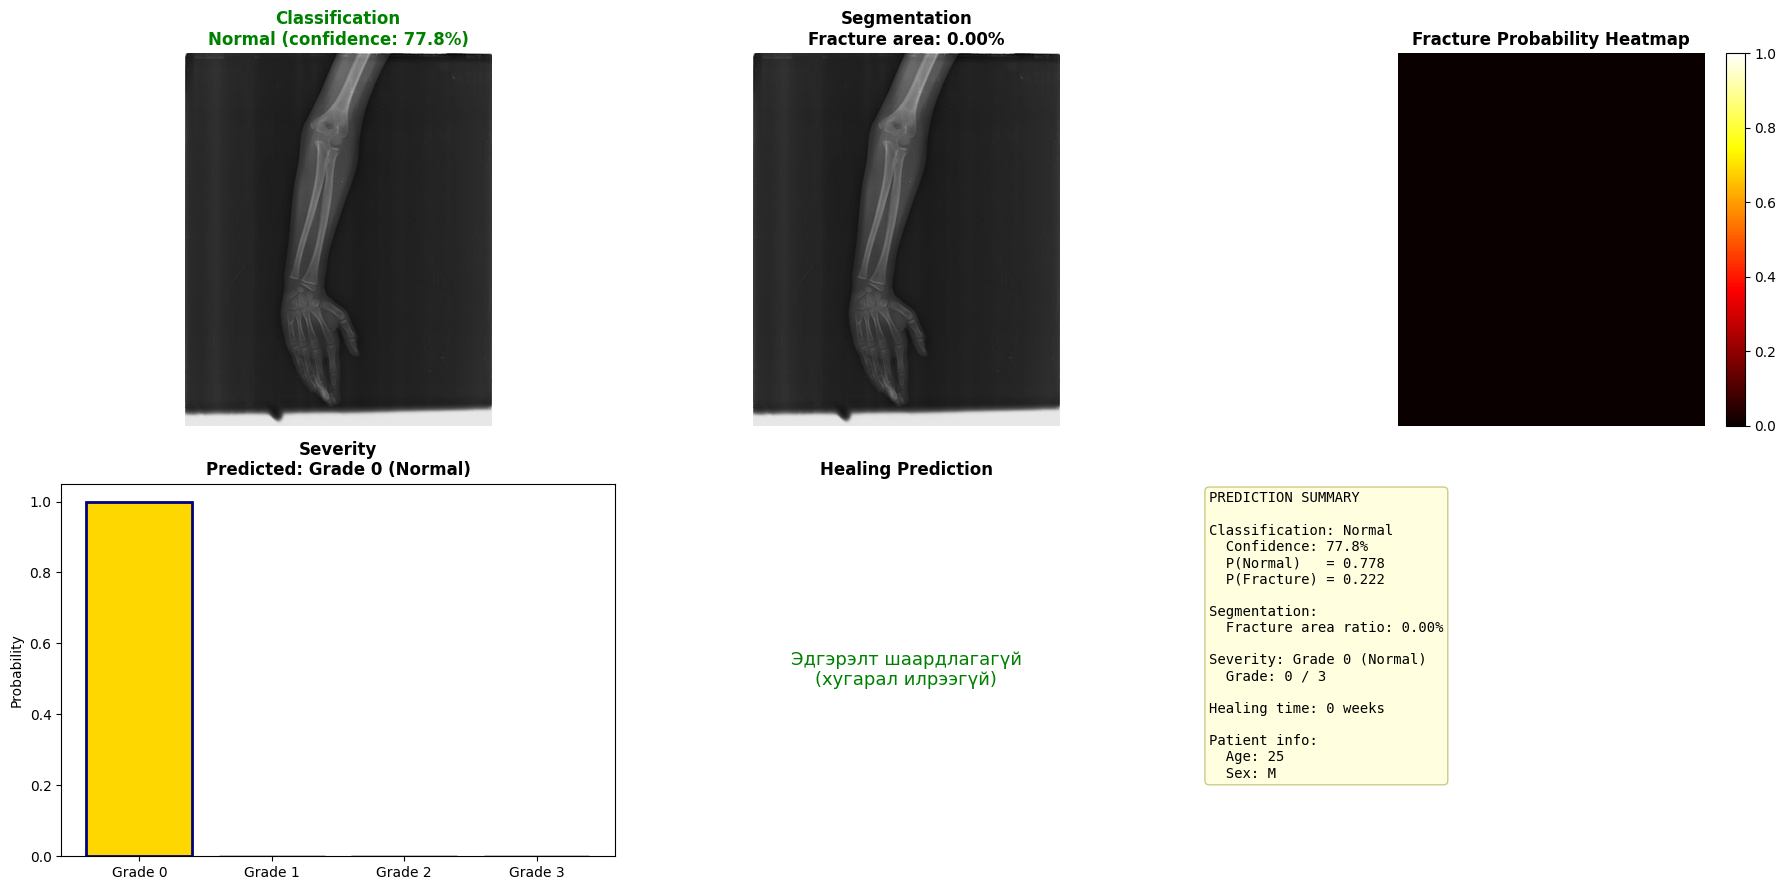


 [5/10] IMG0003381.jpg
File          : IMG0003381.jpg
Fracture prob : 0.1225  (threshold 0.2476)
Has fracture  : False


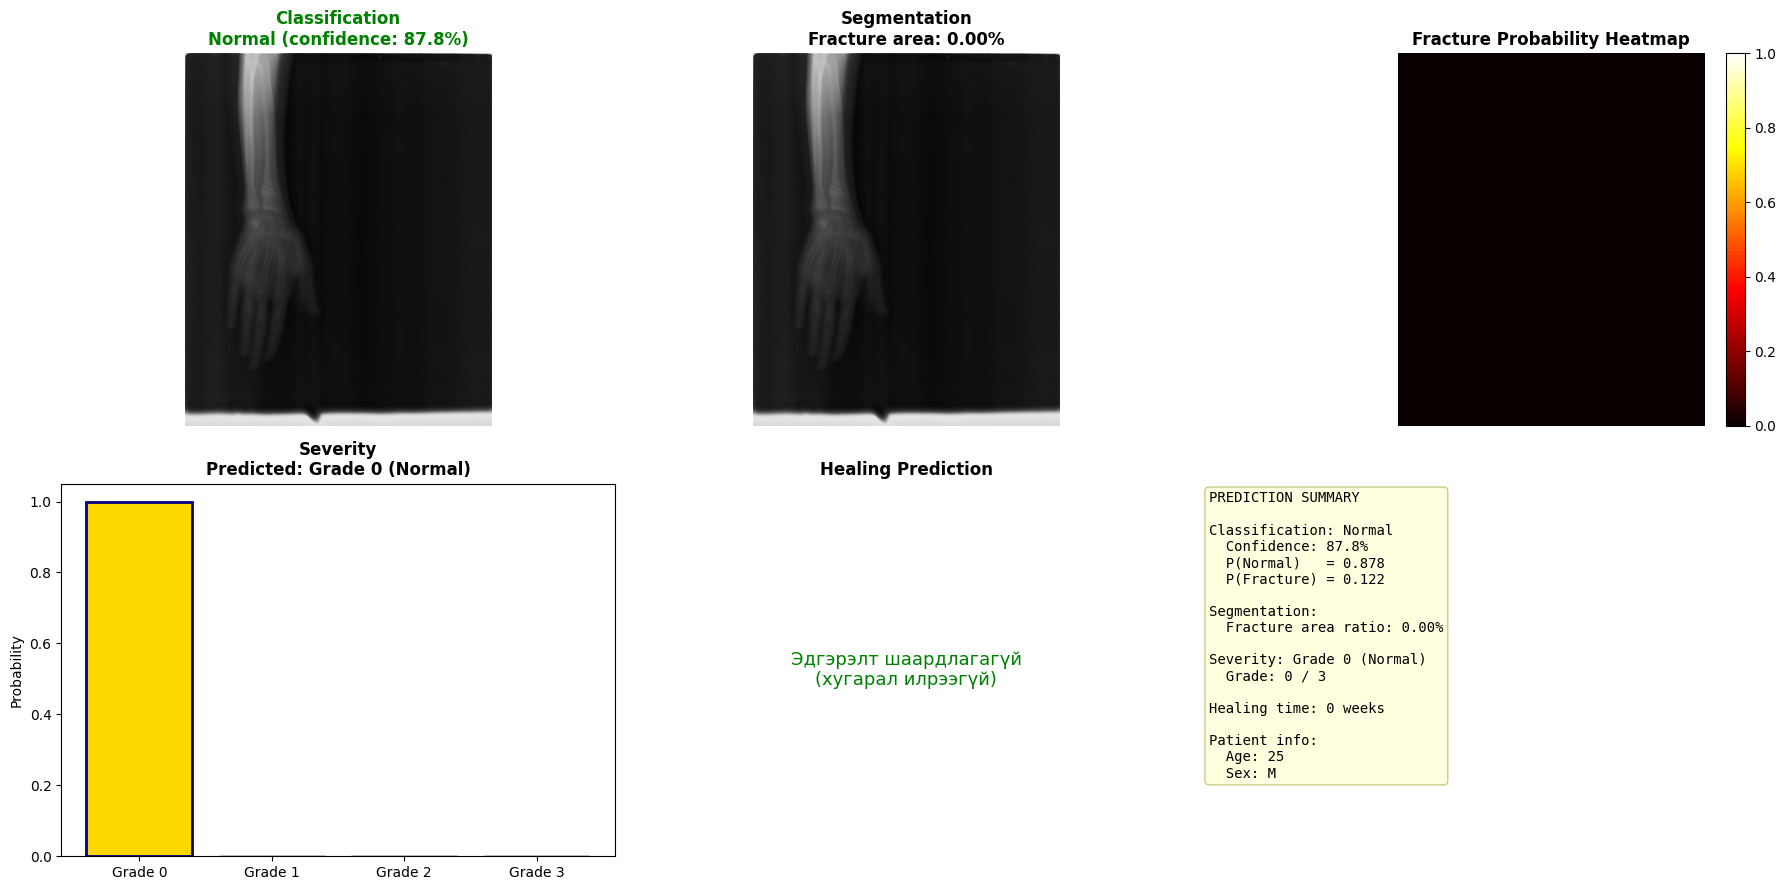


 [6/10] IMG0003373.jpg
File          : IMG0003373.jpg
Fracture prob : 0.9233  (threshold 0.2476)
Has fracture  : True
Severity      : Class 1
Recovery      : Бага зэргийн хугарал — 4-6 долоо хоног
Mask area %   : 0.05


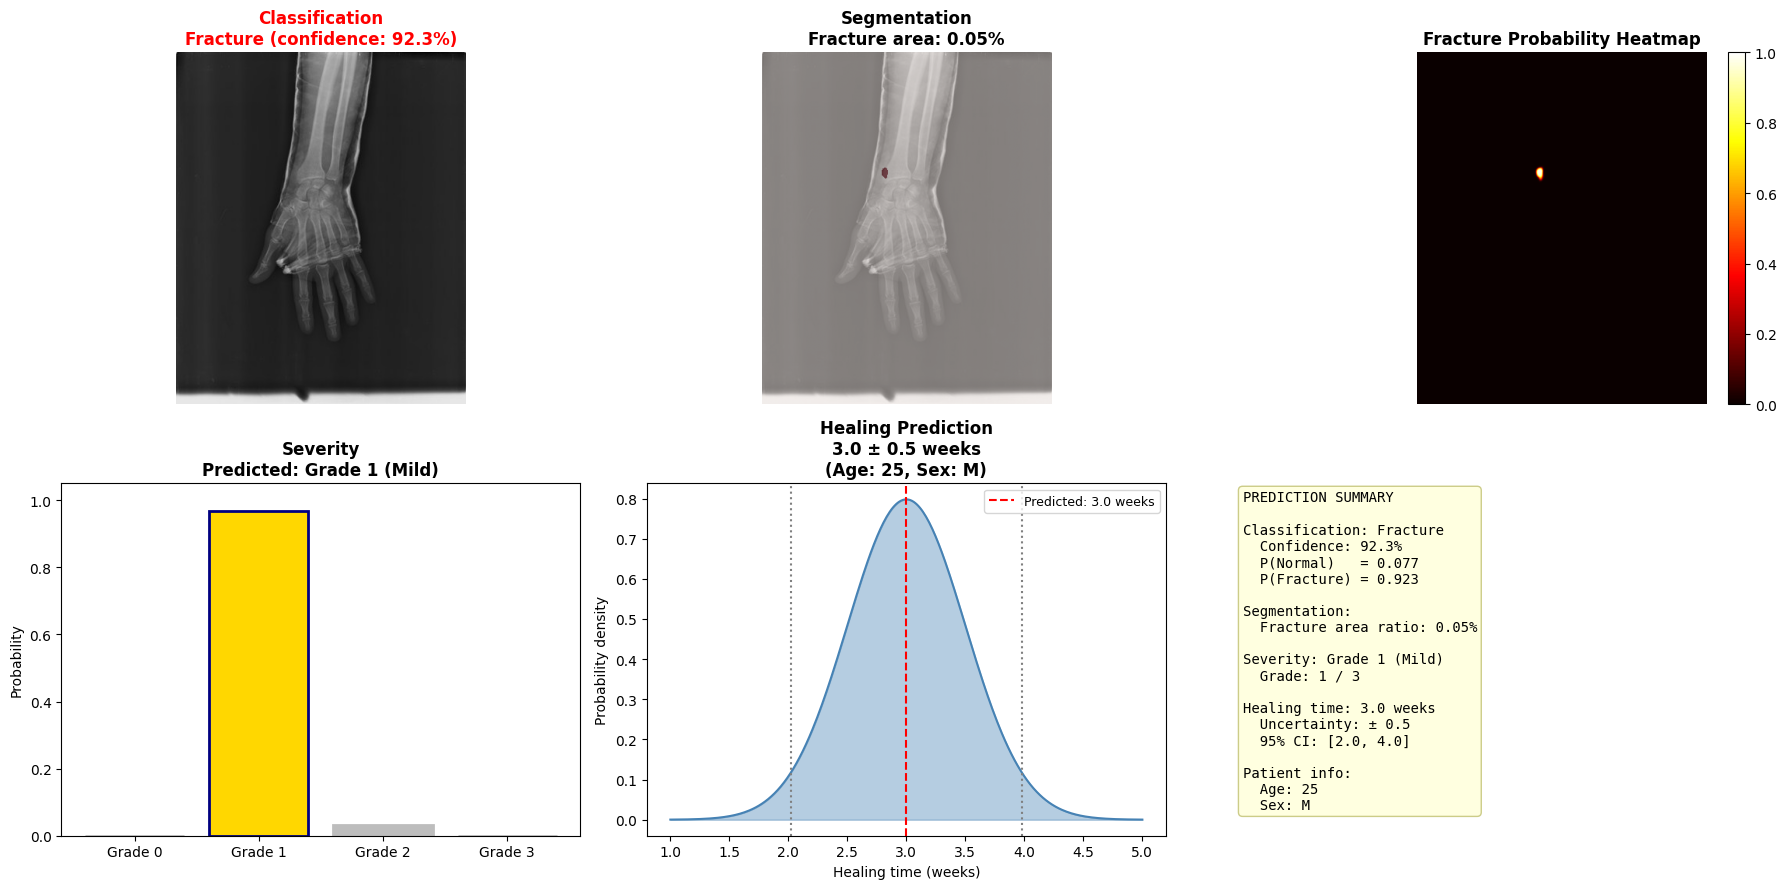


 [7/10] IMG0003342.jpg
File          : IMG0003342.jpg
Fracture prob : 0.9287  (threshold 0.2476)
Has fracture  : True
Severity      : Class 2
Recovery      : Дунд зэргийн хугарал — 7-10 долоо хоног
Mask area %   : 1.87


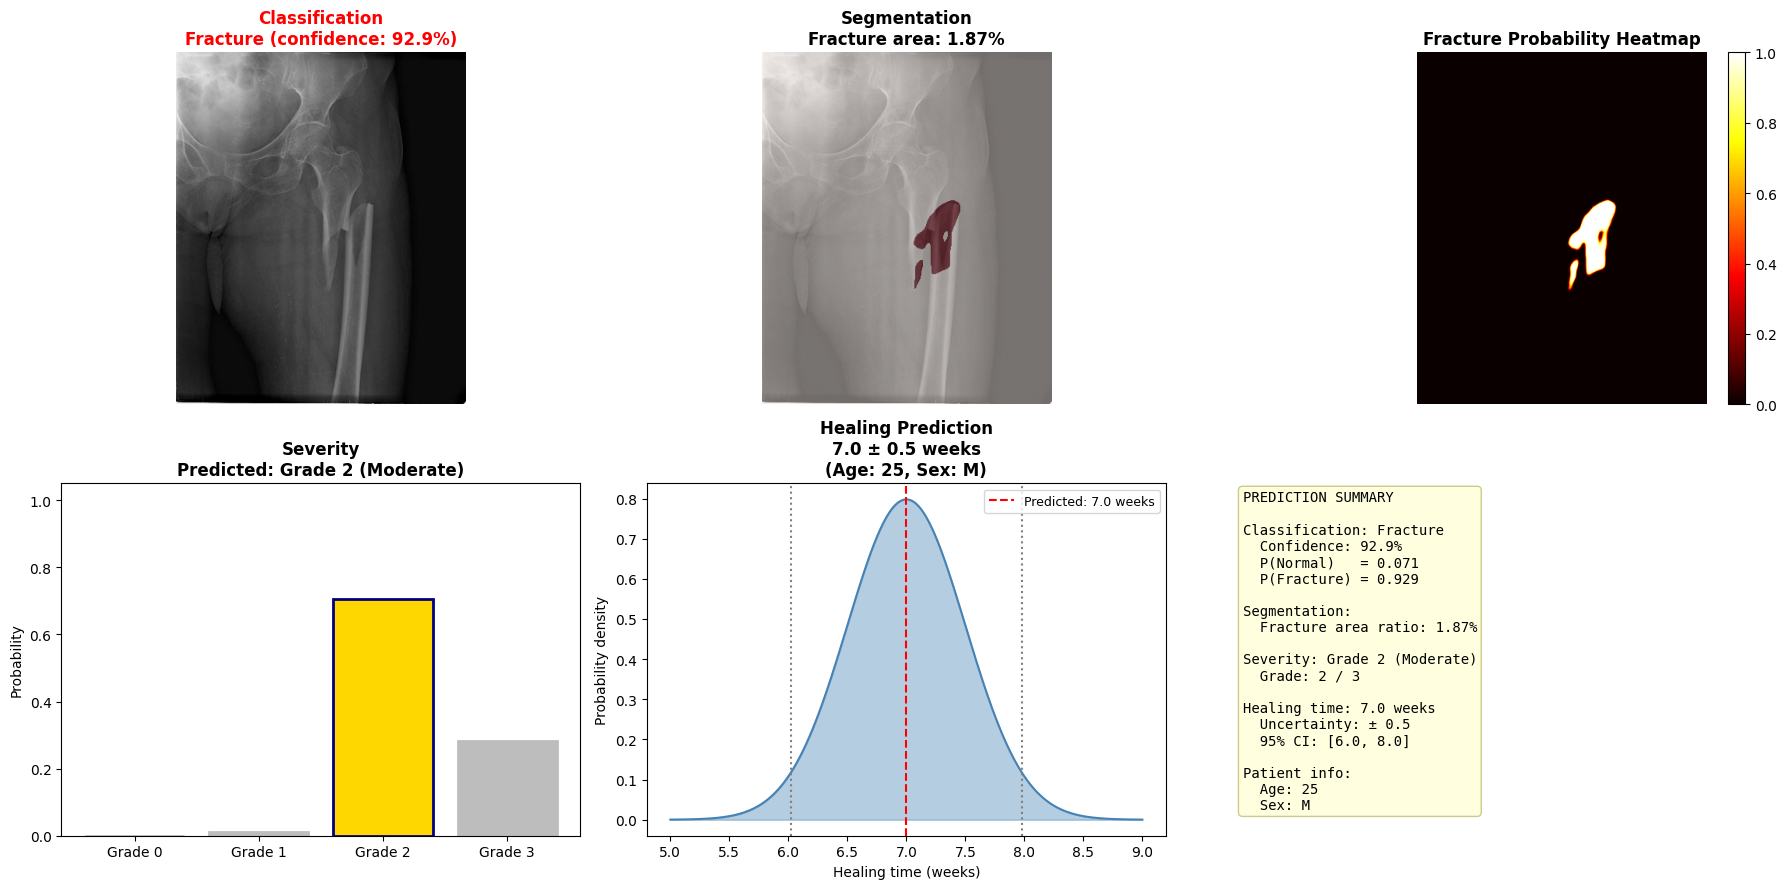


 [8/10] IMG0003313.jpg
File          : IMG0003313.jpg
Fracture prob : 0.9195  (threshold 0.2476)
Has fracture  : True
Severity      : Class 1
Recovery      : Бага зэргийн хугарал — 4-6 долоо хоног
Mask area %   : 0.18


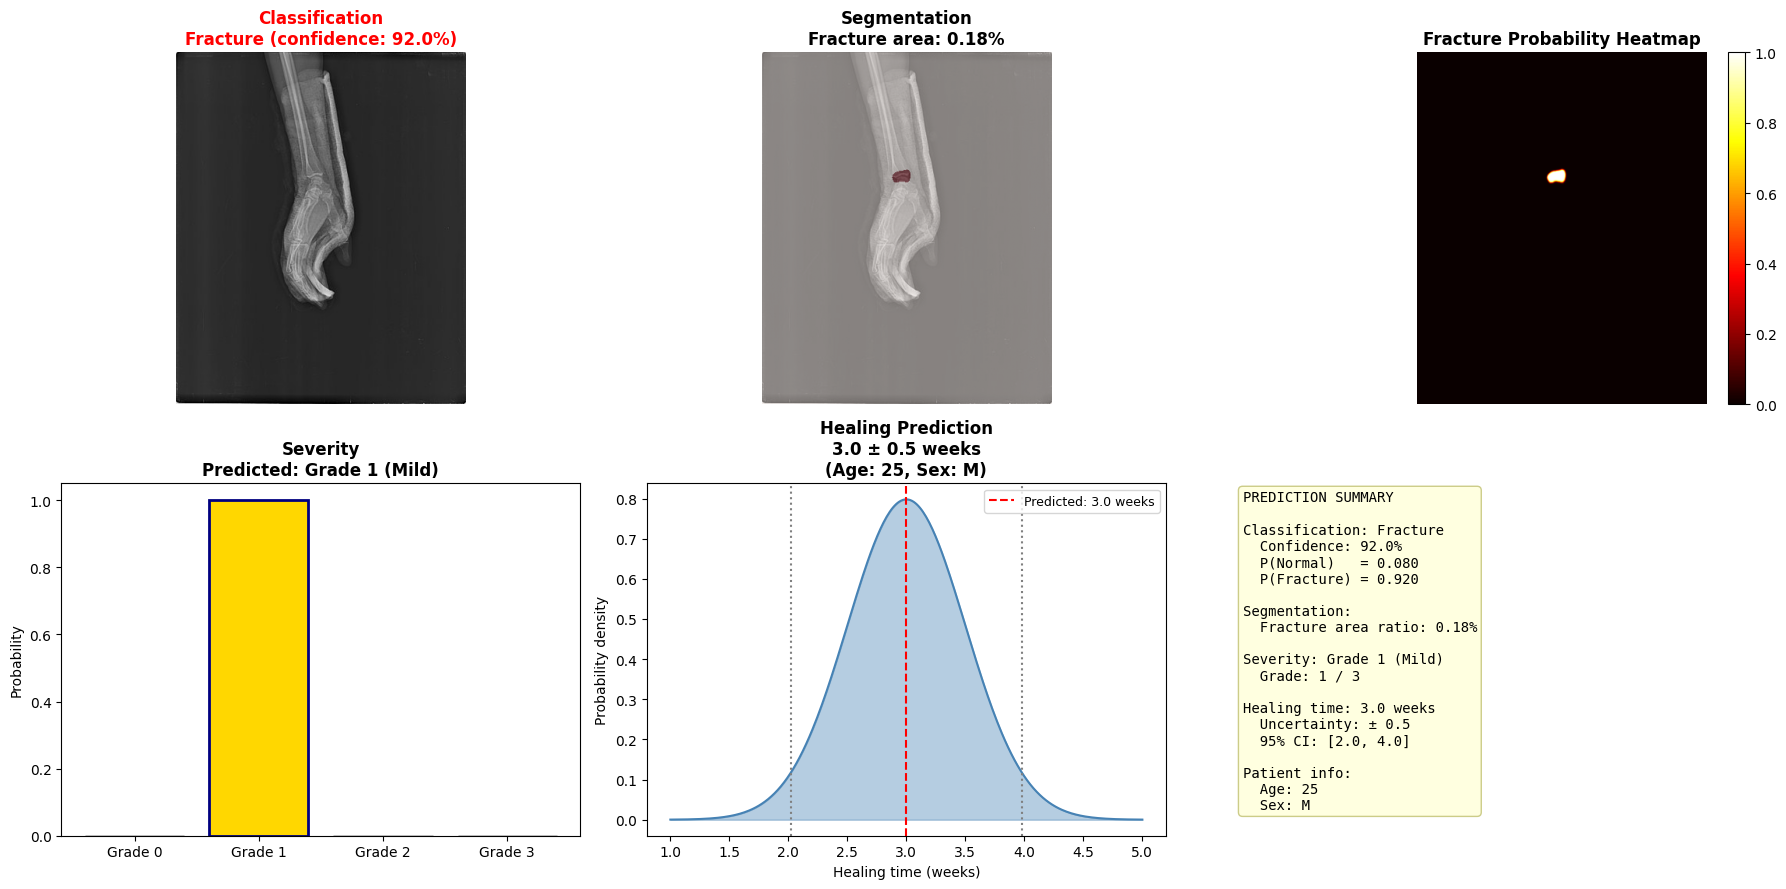


 [9/10] IMG0003704.jpg
File          : IMG0003704.jpg
Fracture prob : 0.7542  (threshold 0.2476)
Has fracture  : True
Severity      : Class 0
Recovery      : Хугарал байхгүй — эмчилгээ шаардлагагүй
Mask area %   : 0.00


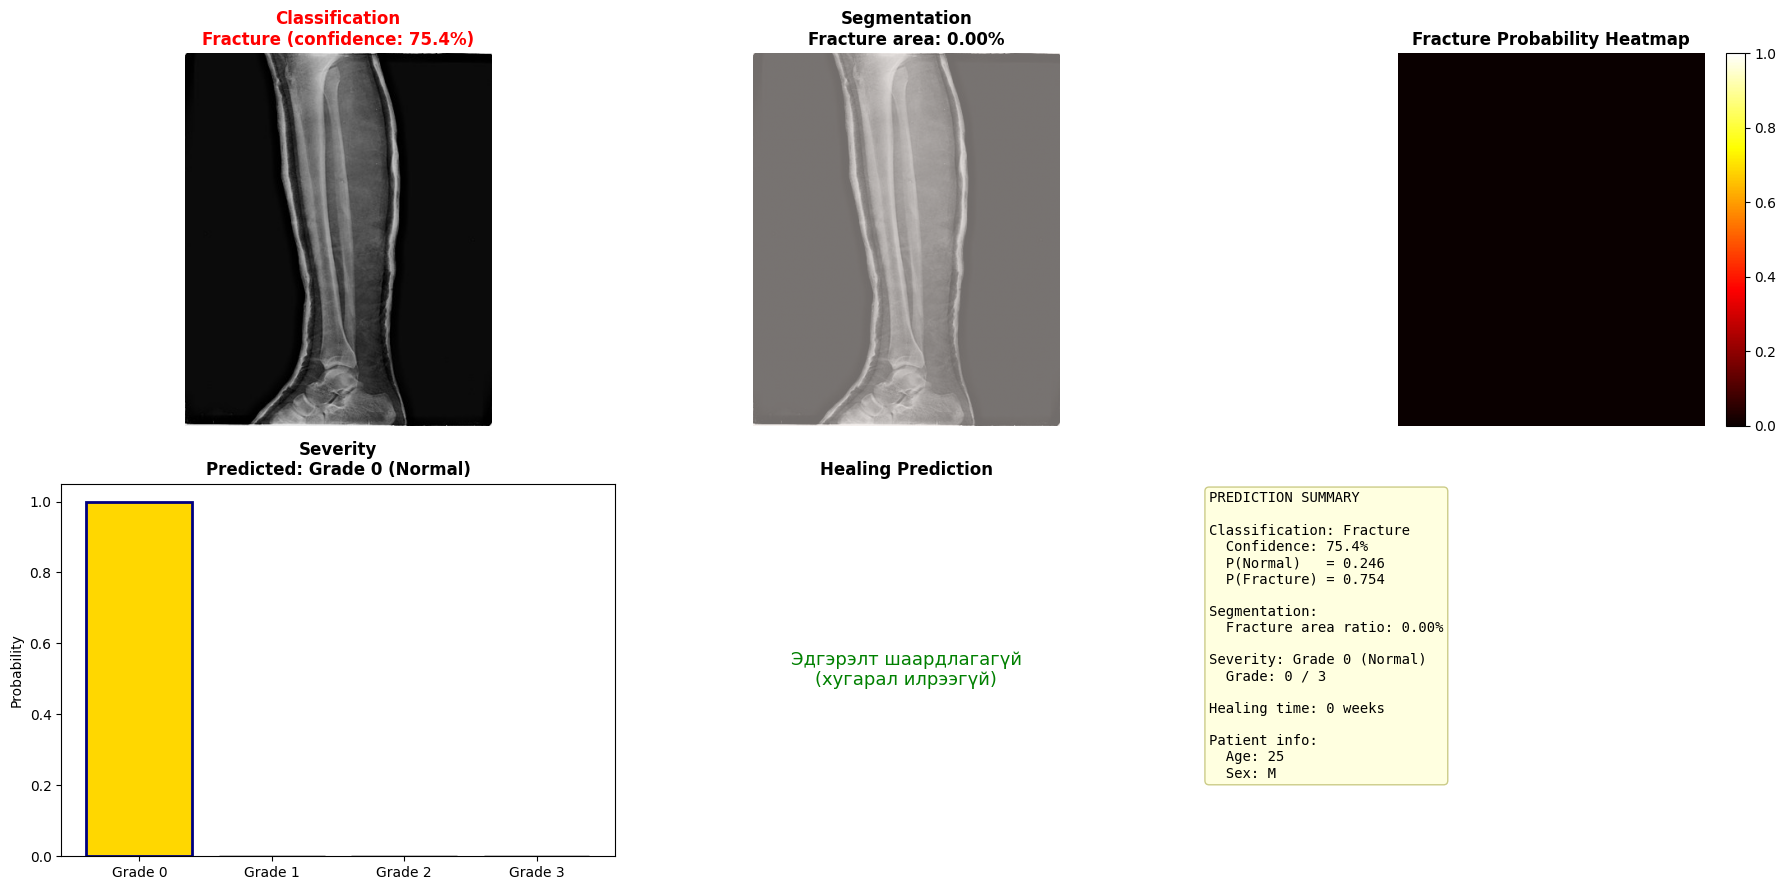


 [10/10] IMG0003311.jpg
File          : IMG0003311.jpg
Fracture prob : 0.0770  (threshold 0.2476)
Has fracture  : False


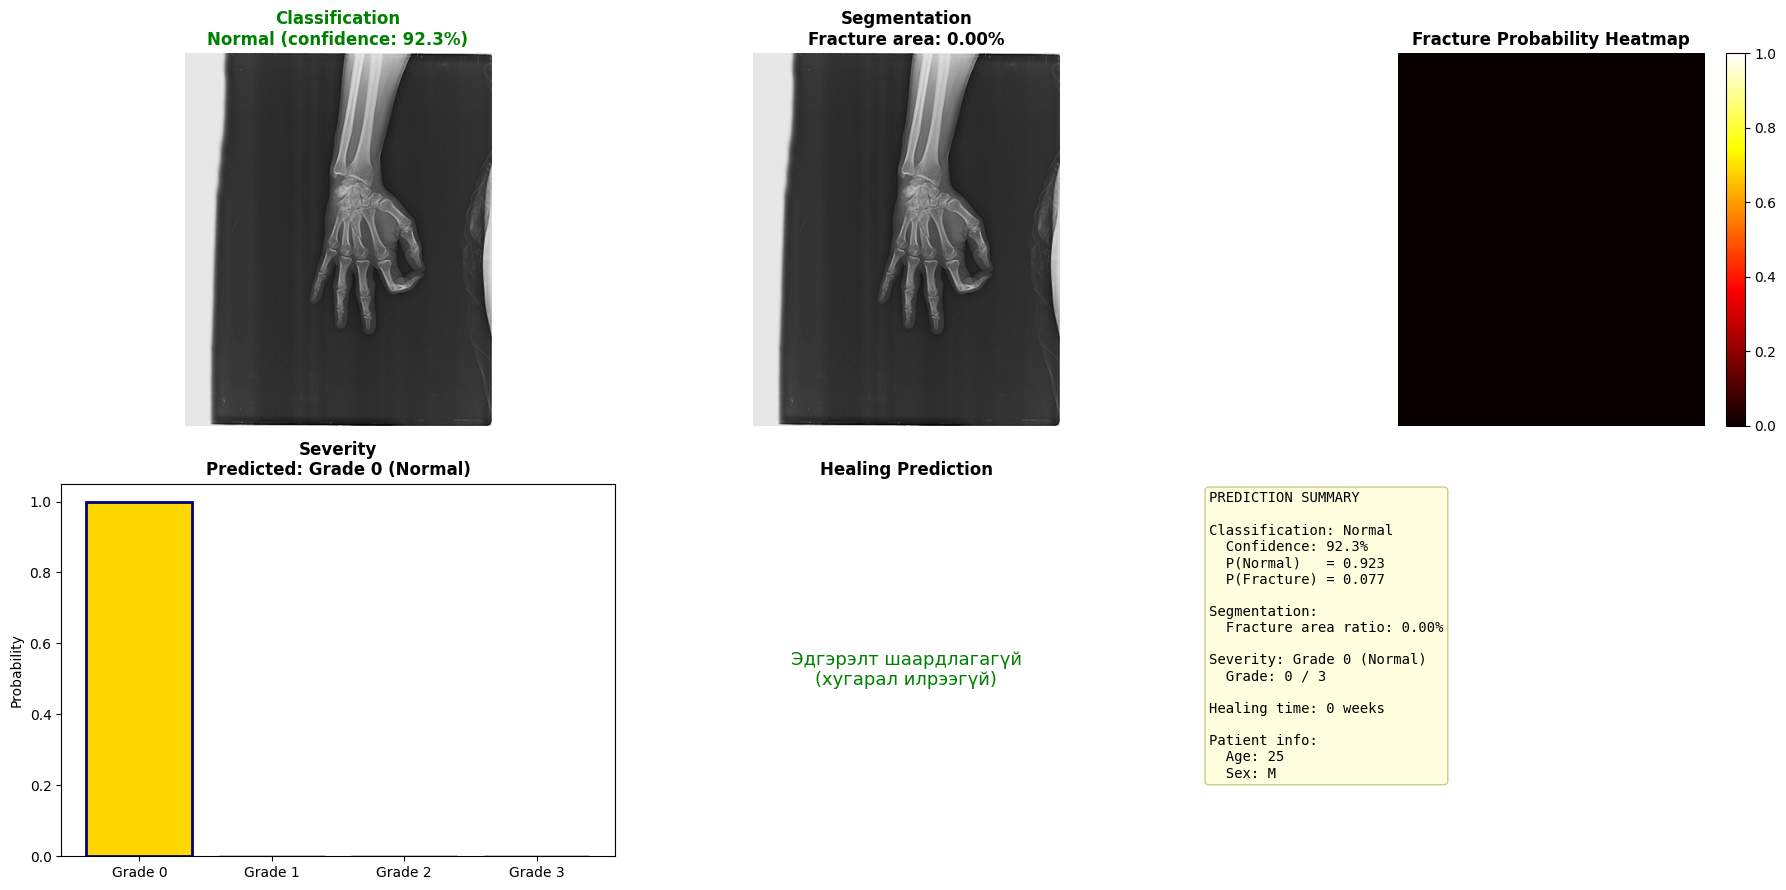

In [13]:
# === DEMO (local) — FracAtlas test set-ээс N зураг дээр pipeline ажиллуулна ===
# fracatlas-DatasetNinja/test/img доторх зургуудаас санамсаргүй N ширхгийг сонгож,
# тус бүрийг бүх 3 шатаар (classification → segmentation → severity) явуулна.
N_DEMO = 10   # хэдэн зураг дээр ажиллуулахыг энд тохируулна

# Өвчтөний мэдээлэл — healing prediction-д ашиглана (demo утга)
DEMO_AGE = 25
DEMO_SEX = 'M'

# FracAtlas test/img доторх бүх зураг (jpg + png)
sample_imgs = sorted(glob.glob(f'{FA_TEST_DIR}/img/*.jpg')) + \
              sorted(glob.glob(f'{FA_TEST_DIR}/img/*.png'))

if sample_imgs:
    random.seed(42)
    DEMO_IMAGES = random.sample(sample_imgs, min(N_DEMO, len(sample_imgs)))
    print(f'FracAtlas test-ээс {len(DEMO_IMAGES)} зураг сонгов '
          f'(нийт {len(sample_imgs)} зургаас).')
else:
    DEMO_IMAGES = []
    print(f'⚠ Зураг алга: {FA_TEST_DIR}/img/ — замаа шалгана уу.')

for i, path in enumerate(DEMO_IMAGES, 1):
    if not os.path.exists(path):
        print(f'⚠ Олдсонгүй: {path}')
        continue
    print(f'\n{"="*70}\n [{i}/{len(DEMO_IMAGES)}] {os.path.basename(path)}\n{"="*70}')
    r = predict_full(path, verbose=True)
    visualize_prediction(r, age=DEMO_AGE, sex=DEMO_SEX)


## 8b. Зураг сонгож (upload) predict хийх

Доорх cell-ийг ажиллуулахад **файл сонгох цонх** нээгдэнэ. X-ray зургаа сонгоход бүх pipeline ажиллаж, 6-panel dashboard гарна. (Local дээр Colab-ийн `files.upload()` ажиллахгүй тул native file dialog ашиглав.)


 IMG0002601.jpg
File          : IMG0002601.jpg
Fracture prob : 0.8458  (threshold 0.2476)
Has fracture  : True
Severity      : Class 1
Recovery      : Бага зэргийн хугарал — 4-6 долоо хоног
Mask area %   : 0.52


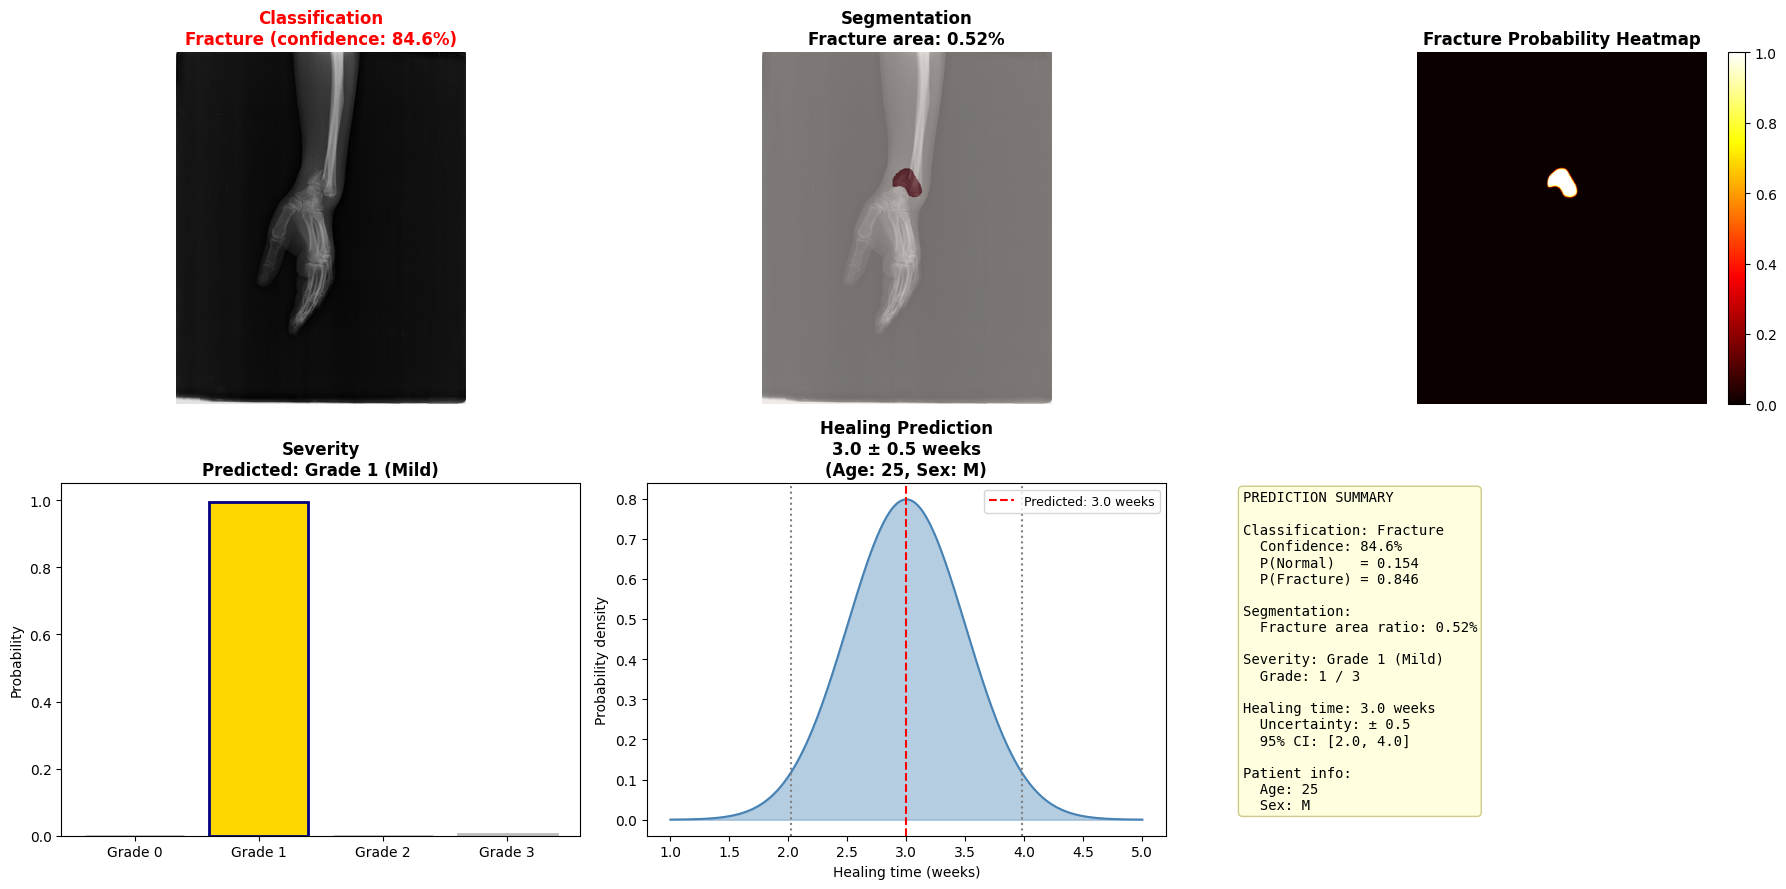

In [14]:

import subprocess

UPLOAD_AGE  = 25      # өвчтөний нас (healing prediction-д ашиглана)
UPLOAD_SEX  = 'M'     # хүйс
UPLOAD_PATH = None    # цонх ажиллахгүй бол энд зургийн замаа бич: '/Users/.../xray.png'


def choose_image_macos():
    """macOS native file picker (osascript) → сонгосон зургийн зам, эсвэл None (cancel)."""
    script = (
        'POSIX path of (choose file with prompt "X-ray зураг сонгоно уу" '
        'of type {"public.image"})'
    )
    try:
        out = subprocess.run(['osascript', '-e', script],
                             capture_output=True, text=True, timeout=300)
        path = out.stdout.strip()
        if not path:
            # Cancel дарвал stderr-д "User canceled" гарна — алдаа биш
            return None
        return path
    except Exception as e:
        print('⚠ File dialog нээгдсэнгүй:', e,
              '\n→ UPLOAD_PATH-д зургийн замаа бичээд дахин ажиллуулна уу.')
        return None


if UPLOAD_PATH is None:
    UPLOAD_PATH = choose_image_macos()

if UPLOAD_PATH and os.path.exists(UPLOAD_PATH):
    print(f'\n{"="*70}\n {os.path.basename(UPLOAD_PATH)}\n{"="*70}')
    r = predict_full(UPLOAD_PATH, verbose=True)
    visualize_prediction(r, age=UPLOAD_AGE, sex=UPLOAD_SEX)
elif UPLOAD_PATH:
    print('Олдсонгүй:', UPLOAD_PATH)
else:
    print(' Зураг сонгоогүй.')
